# TP2 — Bank Marketing

Objetivo: predecir si un cliente contratará un depósito a plazo fijo (`y = yes/no`) y comparar Naive Bayes, SVM, KNN y Random Forest mediante validación cruzada. El conjunto de test se reserva antes del EDA usado para tomar decisiones. [P02, p. 1] [P02, p. 2]

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
DATA_PATH = Path('../../material/externo/datasets/bank-additional-full.csv')

sns.set_theme(style='whitegrid')

## 1. Carga y verificación de integridad

En esta etapa sólo verificamos identidad, esquema, codificación de faltantes y consistencia interna. Las distribuciones y relaciones con `y` que influyan en decisiones del pipeline se analizarán después de reservar test.

Hay dos excepciones, porque definen cómo se construye la partición: el balance de clases (para estratificar) y el orden temporal de las filas, que documenta la descripción del dataset. [D03]

In [2]:
df = pd.read_csv(DATA_PATH, sep=';')

numeric_features = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
]
categorical_features = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome',
]
target = 'y'

expected_columns = [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
    'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
]
assert df.shape == (41188, 21)
assert df.columns.tolist() == expected_columns
assert all(pd.api.types.is_numeric_dtype(df[c]) for c in numeric_features)
assert all(df[c].dtype == object for c in categorical_features + [target])
assert set(df[target].unique()) == {'no', 'yes'}
assert df.isna().sum().sum() == 0

duplicate_mask = df.duplicated(keep='first')
assert duplicate_mask.sum() == 12
assert not df.drop(columns=target).duplicated(keep=False).loc[~df.duplicated(keep=False)].any()
df_model = df.loc[~duplicate_mask].copy()
assert df_model.shape == (41176, 21)

print(f'Filas: {len(df)}; columnas: {df.shape[1]}; NaN: {df.isna().sum().sum()}')
print(f'Duplicados exactos eliminados de la copia de trabajo: {duplicate_mask.sum()}')

Filas: 41188; columnas: 21; NaN: 0
Duplicados exactos eliminados de la copia de trabajo: 12


### 1.1 Faltantes codificados y consistencia

La descripción del dataset indica que los faltantes de las categóricas están codificados como `unknown` y que `pdays = 999` significa que el cliente no fue contactado en una campaña previa. [D03] Por eso `isna()` no alcanza para detectarlos.

In [3]:
unknown = (
    df_model[categorical_features]
    .eq('unknown')
    .sum()
    .loc[lambda s: s > 0]
    .to_frame('cantidad')
    .assign(porcentaje=lambda t: 100 * t['cantidad'] / len(df_model))
)
display(unknown.round(2))

consistency = pd.crosstab(
    df_model['poutcome'],
    df_model['pdays'].eq(999).map({True: 'pdays = 999', False: 'pdays < 999'}),
)
display(consistency)
print(f"Clientes con previous = 0: {(df_model['previous'] == 0).sum()}")

,cantidad,porcentaje
job,330,0.80
marital,80,0.19
education,1730,4.20
default,8596,20.88
housing,990,2.40
loan,990,2.40


pdays,pdays < 999,pdays = 999
poutcome,,
failure,142,4110
nonexistent,0,35551
success,1373,0


Clientes con previous = 0: 35551


### 1.2 Balance de clases y orden temporal

La descripción del dataset indica que las filas están ordenadas por fecha, de mayo de 2008 a noviembre de 2010, pero no incluye una columna de año. [D03] Como el orden es cronológico, el año se reconstruye contando cada vez que el mes retrocede (por ejemplo, de diciembre a marzo). Esta columna auxiliar sólo se usa para analizar la partición y no es un predictor.

In [4]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_number = df_model['month'].map({m: i for i, m in enumerate(month_order)})
year = 2008 + month_number.diff().lt(0).cumsum()
assert year.min() == 2008 and year.max() == 2010

positive = df_model[target].eq('yes')
print(f'Proporción de yes: {positive.mean():.2%} ({positive.sum()} de {len(df_model)})')

by_year = (
    pd.DataFrame({'anio': year, 'yes': positive})
    .groupby('anio')
    .agg(filas=('yes', 'size'), positivos=('yes', 'sum'), tasa_yes=('yes', 'mean'))
)
display(by_year.style.format({'tasa_yes': '{:.1%}'}))

Proporción de yes: 11.27% (4639 de 41176)


,filas,positivos,tasa_yes
anio,,,
2008,27682,1339,4.8%
2009,11436,2227,19.5%
2010,2058,1073,52.1%


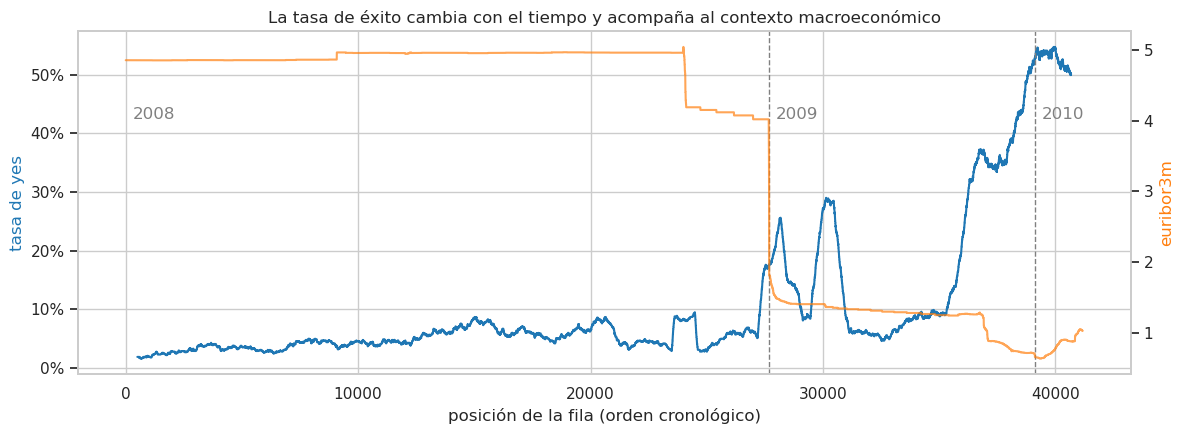

Combinaciones distintas de las 5 variables macro: 375


,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
emp.var.rate,1.00,0.78,0.20,0.97,0.91
cons.price.idx,0.78,1.00,0.06,0.69,0.52
cons.conf.idx,0.20,0.06,1.00,0.28,0.10
euribor3m,0.97,0.69,0.28,1.00,0.95
nr.employed,0.91,0.52,0.10,0.95,1.00


In [5]:
window = 1000
row_position = np.arange(len(df_model))
rolling_rate = positive.astype(float).rolling(window, center=True).mean()

fig, ax_rate = plt.subplots(figsize=(12, 4.5))
ax_rate.plot(row_position, rolling_rate, color='tab:blue', label=f'tasa de yes (ventana de {window} filas)')
ax_rate.set_xlabel('posición de la fila (orden cronológico)')
ax_rate.set_ylabel('tasa de yes', color='tab:blue')
ax_rate.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

ax_macro = ax_rate.twinx()
ax_macro.plot(row_position, df_model['euribor3m'].to_numpy(), color='tab:orange', alpha=0.7, label='euribor3m')
ax_macro.set_ylabel('euribor3m', color='tab:orange')
ax_macro.grid(False)

for boundary in year.diff().ne(0).to_numpy().nonzero()[0]:
    if boundary > 0:
        ax_rate.axvline(boundary, color='gray', linestyle='--', linewidth=1)
    ax_rate.text(boundary + 300, 0.78, str(year.iloc[boundary]), color='gray',
                 va='top', transform=ax_rate.get_xaxis_transform())

ax_rate.set_title('La tasa de éxito cambia con el tiempo y acompaña al contexto macroeconómico')
fig.tight_layout()
plt.show()

macro = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
print(f'Combinaciones distintas de las 5 variables macro: {len(df_model[macro].drop_duplicates())}')
display(df_model[macro].corr().round(2))

## 2. Reserva de test

Se reserva el 20 % para la evaluación final, con un split aleatorio estratificado por `y` para conservar la proporción de positivos (11,3 %) en desarrollo y test. Con 20 % quedan unos 928 positivos en test, lo que hace más estable la estimación de métricas centradas en la clase positiva.

El split aleatorio mezcla los tres años en ambos conjuntos. Por eso la estimación final supone que los datos nuevos se parecen a la mezcla de 2008 a 2010. Las variables macro y `month` permiten al modelo reconocer el período, así que esa estimación será optimista para campañas futuras. Al final se agrega un experimento temporal para cuantificar esa limitación.

Test no se usa para ninguna decisión hasta reentrenar el pipeline final. [P02, p. 1] [T02, p. 89] [T02, p. 94]

In [6]:
TEST_SIZE = 0.20

X = df_model.drop(columns=target)
y = df_model[target].eq('yes').astype(int)

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
year_dev = year.loc[X_dev.index]

assert len(X_dev) == len(y_dev) == 32940
assert len(X_test) == len(y_test) == 8236
assert X_dev.index.intersection(X_test.index).empty
print(f'Desarrollo: {len(X_dev)} filas, {y_dev.sum()} positivos ({y_dev.mean():.2%})')
print(f'Test reservado: {len(X_test)} filas, {y_test.sum()} positivos ({y_test.mean():.2%})')

Desarrollo: 32940 filas, 3711 positivos (11.27%)
Test reservado: 8236 filas, 928 positivos (11.27%)


## 3. EDA de desarrollo

A partir de aquí se trabaja con `X_dev` y `y_dev`. No se inspeccionan distribuciones ni resultados de test hasta seleccionar y reentrenar el pipeline final. [T02, p. 94] [T02, p. 96]

El objetivo no es un análisis exhaustivo: cada observación tiene que traducirse en una decisión sobre el preprocesamiento, la selección de variables o la interpretación de los resultados. [P02, p. 1]

### 3.1 Faltantes y categorías poco frecuentes

In [7]:
dev = X_dev.copy()
dev[target] = y_dev
global_rate = y_dev.mean()

category_rows = []
for column in categorical_features:
    summary = dev.groupby(column)[target].agg(cantidad='size', tasa_yes='mean')
    for category, row in summary.iterrows():
        category_rows.append({
            'variable': column,
            'categoria': category,
            'cantidad': int(row['cantidad']),
            'porcentaje': 100 * row['cantidad'] / len(dev),
            'tasa_yes': 100 * row['tasa_yes'],
        })
category_summary = pd.DataFrame(category_rows)

print('Categorías con menos del 1 % de las filas o codificadas como unknown:')
display(
    category_summary
    .loc[lambda t: (t['porcentaje'] < 1) | (t['categoria'] == 'unknown')]
    .round({'porcentaje': 2, 'tasa_yes': 1})
    .reset_index(drop=True)
)
same_unknown = dev['housing'].eq('unknown').equals(dev['loan'].eq('unknown'))
print(f'Las filas con housing = unknown son las mismas que con loan = unknown: {same_unknown}')

Categorías con menos del 1 % de las filas o codificadas como unknown:


,variable,categoria,cantidad,porcentaje,tasa_yes
0,job,unknown,267,0.81,12.4
1,marital,unknown,68,0.21,16.2
2,education,illiterate,18,0.05,22.2
3,education,unknown,1389,4.22,14.9
4,default,unknown,6857,20.82,5.3
5,default,yes,2,0.01,0.0
6,housing,unknown,779,2.36,11.7
7,loan,unknown,779,2.36,11.7
8,month,dec,145,0.44,50.3


Las filas con housing = unknown son las mismas que con loan = unknown: True


### 3.2 Distribución de las variables numéricas

,count,mean,std,min,25%,50%,75%,max,asimetria
age,32940.0,40.02,10.45,17.00,32.00,38.00,47.00,98.00,0.80
duration,32940.0,257.74,257.50,0.00,102.00,179.00,319.00,4199.00,3.19
campaign,32940.0,2.56,2.77,1.00,1.00,2.00,3.00,56.00,4.89
pdays,32940.0,962.62,186.56,0.00,999.00,999.00,999.00,999.00,-4.93
previous,32940.0,0.17,0.50,0.00,0.00,0.00,0.00,7.00,3.89
emp.var.rate,32940.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40,-0.72
cons.price.idx,32940.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77,-0.23
cons.conf.idx,32940.0,-40.51,4.63,-50.80,-42.70,-41.80,-36.40,-26.90,0.31
euribor3m,32940.0,3.62,1.74,0.63,1.34,4.86,4.96,5.04,-0.71
nr.employed,32940.0,5166.91,72.40,4963.60,5099.10,5191.00,5228.10,5228.10,-1.04


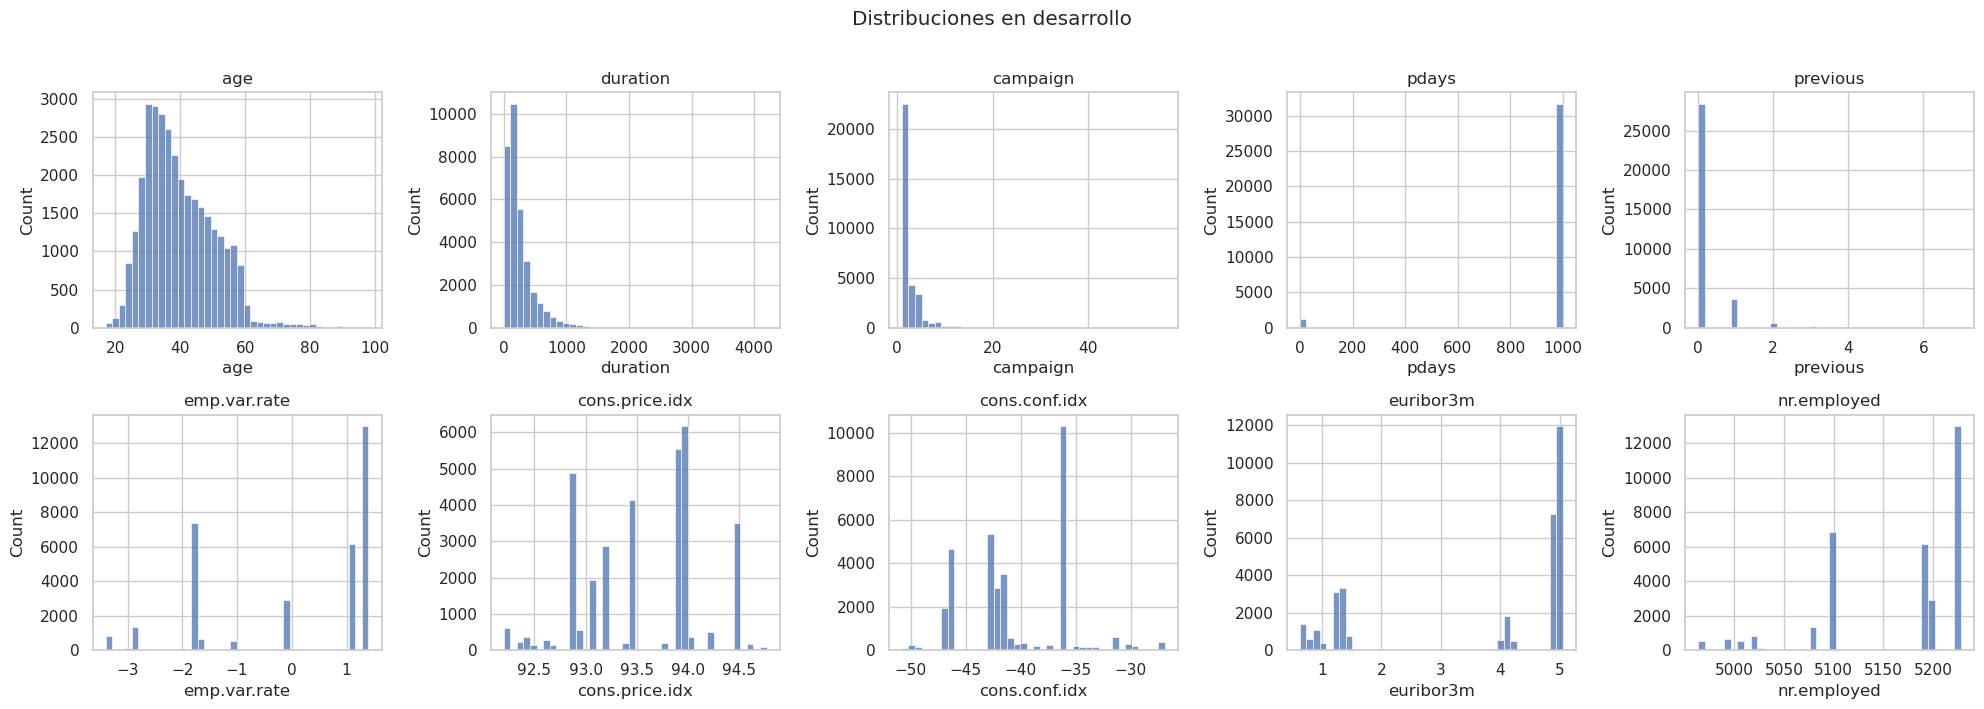

pdays = 999 (sin contacto previo registrado): 96.34%
previous = 0: 86.31%


In [8]:
display(dev[numeric_features].describe().T.round(2).assign(asimetria=dev[numeric_features].skew().round(2)))

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for column, axis in zip(numeric_features, axes.flat):
    sns.histplot(data=dev, x=column, bins=40, ax=axis)
    axis.set_title(column)
plt.suptitle('Distribuciones en desarrollo', y=1.01)
plt.tight_layout()
plt.show()

print(f"pdays = 999 (sin contacto previo registrado): {dev['pdays'].eq(999).mean():.2%}")
print(f"previous = 0: {dev['previous'].eq(0).mean():.2%}")

### 3.3 Tasa de `yes` por categoría

La línea punteada marca la tasa global de desarrollo. Una variable es informativa si sus categorías se alejan de esa línea con suficientes filas.

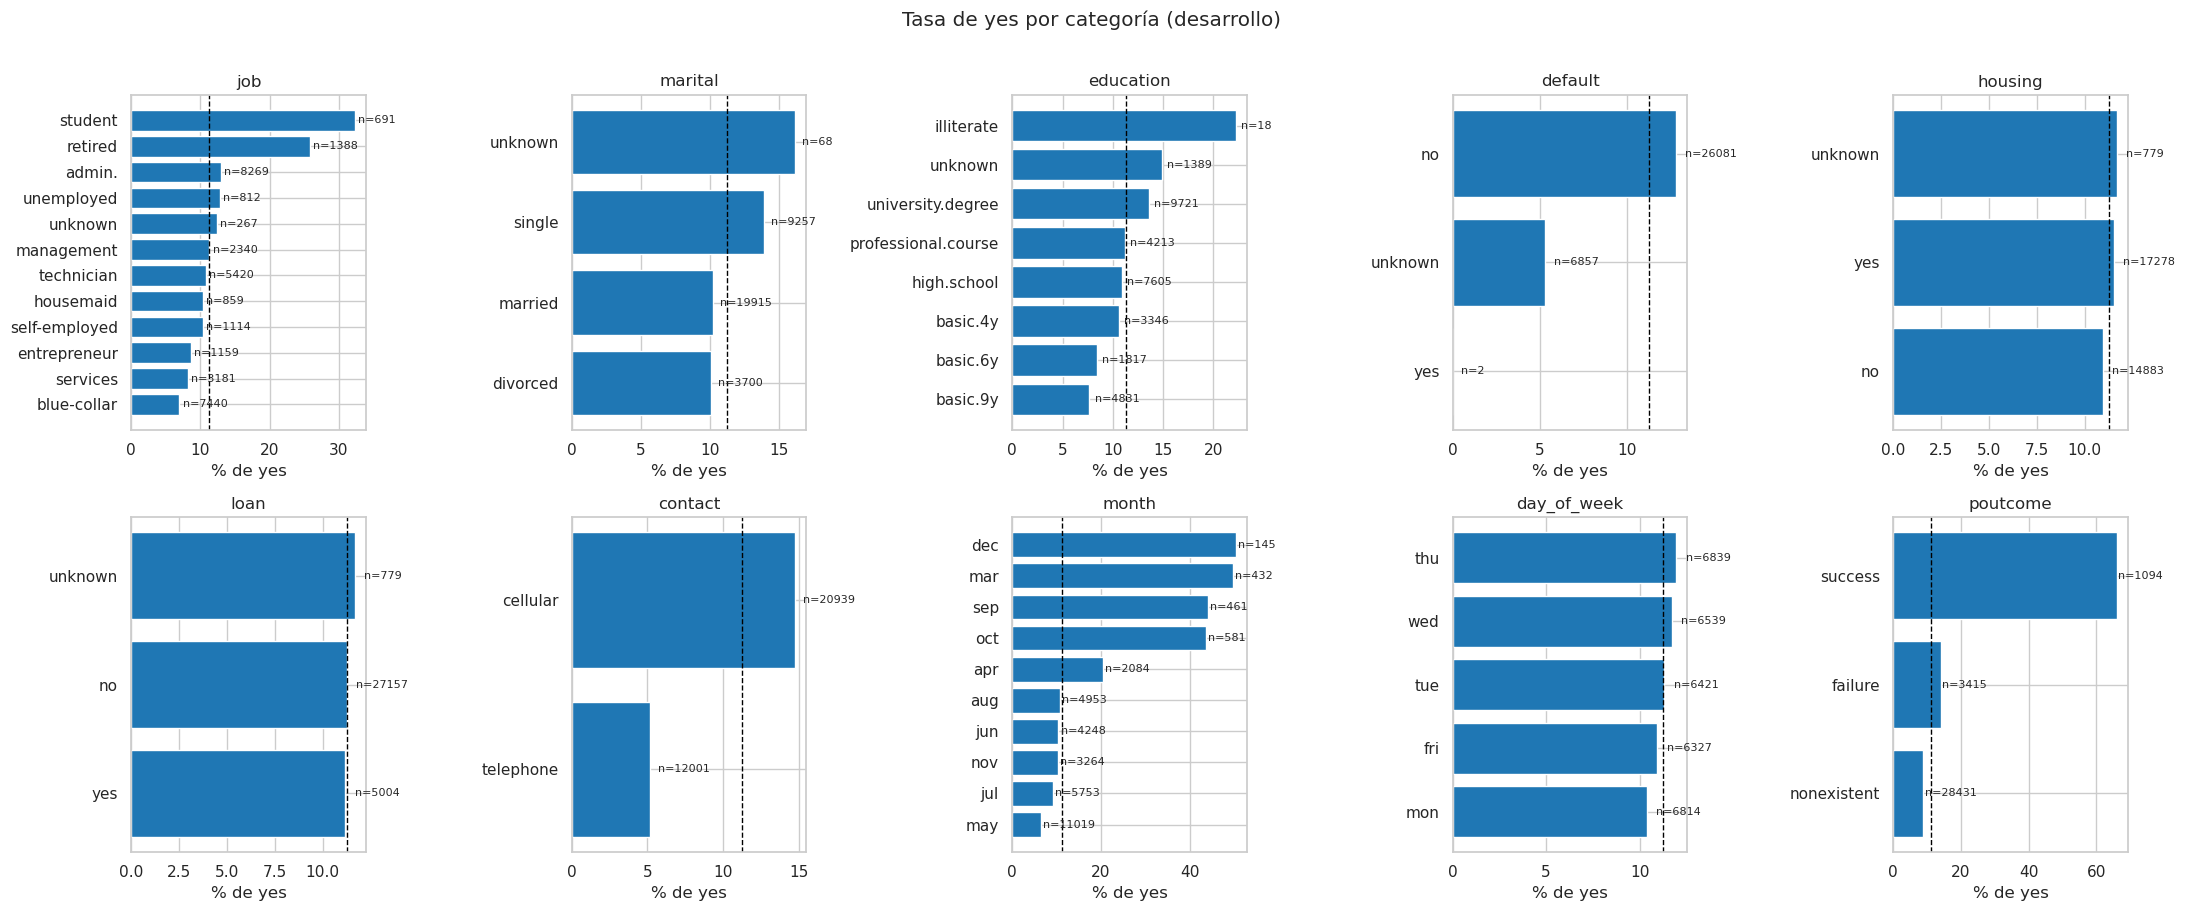

Rango de la tasa de yes entre categorías con al menos 100 filas (puntos porcentuales):


,minima,maxima,rango
variable,,,
loan,11.2,11.7,0.5
housing,11.0,11.7,0.7
day_of_week,10.4,12.0,1.6
marital,10.1,13.9,3.9
education,7.7,14.9,7.2
default,5.3,12.8,7.5
contact,5.2,14.7,9.6
job,6.9,32.3,25.3
month,6.4,50.3,44.0


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for column, axis in zip(categorical_features, axes.flat):
    data = category_summary.loc[category_summary['variable'] == column].sort_values('tasa_yes')
    axis.barh(data['categoria'], data['tasa_yes'], color='tab:blue')
    axis.axvline(100 * global_rate, color='black', linestyle='--', linewidth=1)
    for position, (rate, count) in enumerate(zip(data['tasa_yes'], data['cantidad'])):
        axis.text(rate + 0.5, position, f'n={count}', va='center', fontsize=8)
    axis.set_title(column)
    axis.set_xlabel('% de yes')
plt.suptitle('Tasa de yes por categoría (desarrollo)', y=1.01)
plt.tight_layout()
plt.show()

spread = (
    category_summary.loc[category_summary['cantidad'] >= 100]
    .groupby('variable')['tasa_yes']
    .agg(minima='min', maxima='max')
    .assign(rango=lambda t: t['maxima'] - t['minima'])
    .sort_values('rango')
)
print('Rango de la tasa de yes entre categorías con al menos 100 filas (puntos porcentuales):')
display(spread.round(1))

### 3.4 Variables numéricas frente a `y`

Pearson y otras medidas lineales no capturan relaciones no monótonas. [T03, p. 49] [T03, p. 51] Por eso, además de comparar distribuciones por clase, se mira la tasa de `yes` por tramos de edad.

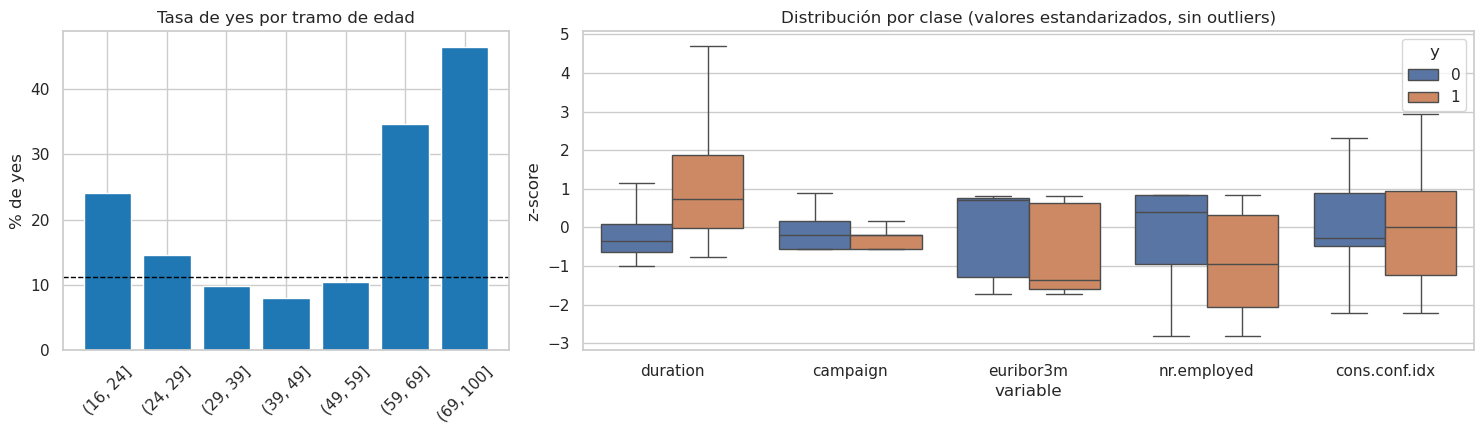

,filas,tasa_yes
age,,
"(16, 24]",853,24.2
"(24, 29]",3737,14.7
"(29, 39]",13507,9.8
"(39, 49]",8426,8.0
"(49, 59]",5440,10.5
"(59, 69]",594,34.7
"(69, 100]",383,46.5


In [10]:
age_bins = pd.cut(dev['age'], bins=[16, 24, 29, 39, 49, 59, 69, 100])
age_rate = dev.groupby(age_bins, observed=True)[target].agg(filas='size', tasa_yes='mean')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={'width_ratios': [1, 2]})
axes[0].bar(age_rate.index.astype(str), 100 * age_rate['tasa_yes'], color='tab:blue')
axes[0].axhline(100 * global_rate, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Tasa de yes por tramo de edad')
axes[0].set_ylabel('% de yes')
axes[0].tick_params(axis='x', rotation=45)

compare = ['duration', 'campaign', 'euribor3m', 'nr.employed', 'cons.conf.idx']
long = dev[compare + [target]].melt(id_vars=target, var_name='variable', value_name='valor')
long['valor_estandarizado'] = long.groupby('variable')['valor'].transform(lambda v: (v - v.mean()) / v.std())
sns.boxplot(data=long, x='variable', y='valor_estandarizado', hue=target, showfliers=False, ax=axes[1])
axes[1].set_title('Distribución por clase (valores estandarizados, sin outliers)')
axes[1].set_ylabel('z-score')
plt.tight_layout()
plt.show()
display(age_rate.assign(tasa_yes=lambda t: (100 * t['tasa_yes']).round(1)))

### 3.5 Poder discriminante univariado

Para cada variable numérica se calcula el AUC que se obtendría ordenando a los clientes sólo por esa variable. No se ajusta ningún modelo: es un filtro rápido sobre desarrollo. [T03, p. 62] Un AUC de 0,5 indica que la variable, por sí sola y de forma monótona, no ordena a los positivos por encima de los negativos. Si el AUC queda por debajo de 0,5, la relación es inversa y se informa `1 − AUC`. [T04, p. 51]

In [11]:
univariate = []
for column in numeric_features:
    auc = roc_auc_score(y_dev, dev[column])
    univariate.append({
        'variable': column,
        'auc': max(auc, 1 - auc),
        'sentido': 'directo' if auc >= 0.5 else 'inverso',
    })
univariate = pd.DataFrame(univariate).sort_values('auc', ascending=False).reset_index(drop=True)
display(univariate.round(3))

,variable,auc,sentido
0,duration,0.818,directo
1,nr.employed,0.745,inverso
2,euribor3m,0.740,inverso
3,emp.var.rate,0.713,inverso
4,previous,0.609,directo
5,cons.price.idx,0.607,inverso
6,pdays,0.598,inverso
7,campaign,0.552,inverso
8,cons.conf.idx,0.537,directo
9,age,0.507,inverso


### 3.6 Correlaciones entre predictores numéricos

Variables muy correlacionadas aportan información redundante. Esto afecta al supuesto de independencia de Naive Bayes y a las distancias de KNN. [T06, p. 38] [T09, p. 39] [T07, p. 72]

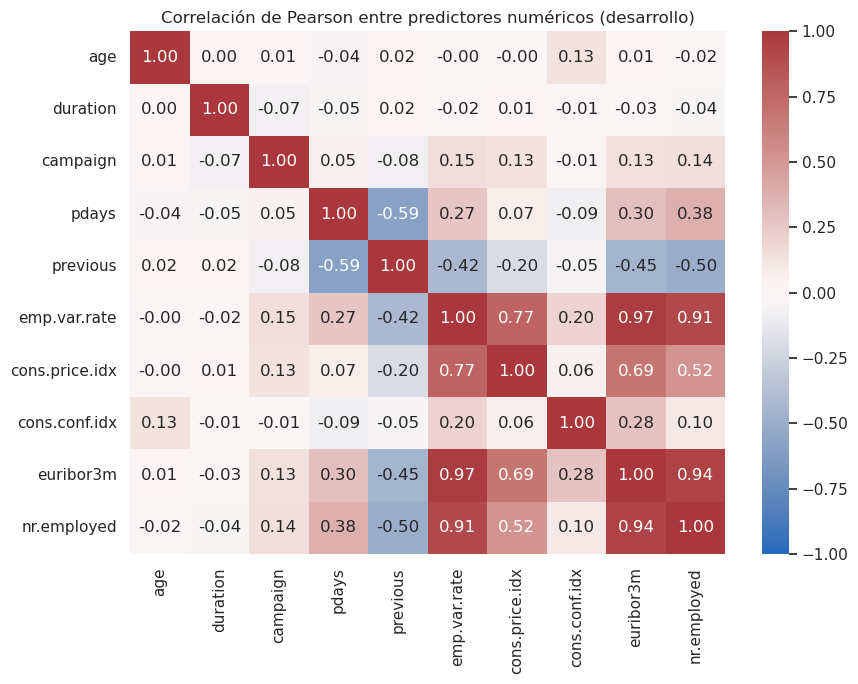

Pares con |r| >= 0,7:


r
emp.var.rate euribor3m       0.97
euribor3m    nr.employed     0.94
emp.var.rate nr.employed     0.91
             cons.price.idx  0.77

In [12]:
correlation = dev[numeric_features].corr()
fig, axis = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=axis)
axis.set_title('Correlación de Pearson entre predictores numéricos (desarrollo)')
plt.tight_layout()
plt.show()

pairs = (
    correlation.where(np.triu(np.ones(correlation.shape, dtype=bool), k=1))
    .stack()
    .loc[lambda s: s.abs() >= 0.7]
    .sort_values(key=np.abs, ascending=False)
)
print('Pares con |r| >= 0,7:')
display(pairs.round(2).to_frame('r'))

### 3.7 `duration` y data leakage

La consigna pide analizar variables que no estarían disponibles antes de la llamada, que es el momento en que operaría el modelo. [P02, p. 1] La documentación del dataset advierte que `duration` determina fuertemente `y` (por ejemplo, `duration = 0` implica `y = no`), que no se conoce antes de llamar, y que debe descartarse en un modelo predictivo realista. [D03]

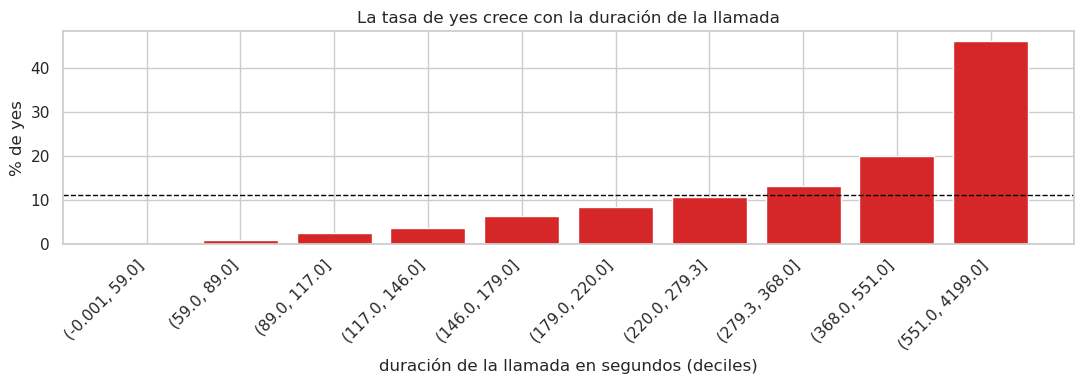

duration = 0: 4 filas, todas con y = {0}


In [13]:
duration_bins = pd.qcut(dev['duration'], q=10)
duration_rate = dev.groupby(duration_bins, observed=True)[target].mean()

fig, axis = plt.subplots(figsize=(11, 4))
axis.bar(range(len(duration_rate)), 100 * duration_rate.to_numpy(), color='tab:red')
axis.set_xticks(range(len(duration_rate)), [str(i) for i in duration_rate.index], rotation=45, ha='right')
axis.axhline(100 * global_rate, color='black', linestyle='--', linewidth=1)
axis.set_ylabel('% de yes')
axis.set_xlabel('duración de la llamada en segundos (deciles)')
axis.set_title('La tasa de yes crece con la duración de la llamada')
plt.tight_layout()
plt.show()
print(f"duration = 0: {dev['duration'].eq(0).sum()} filas, todas con y = {set(dev.loc[dev['duration'].eq(0), target])}")

### 3.8 Decisiones tras el EDA

| Observación | Decisión |
|---|---|
| `duration` se conoce recién al terminar la llamada y determina fuertemente `y`. [D03] | Se excluye de todos los modelos. Se mide una sola vez cuánto inflaría las métricas (benchmark, sección 6.2). [P02, p. 1] |
| `default = unknown` acepta menos (5,3 % frente a 12,8 %) y `default = yes` tiene 2 filas. | `default` pasa a `default_no`: 1 si consta que no está en mora, 0 si es `unknown` o `yes`. |
| `education = illiterate` tiene 18 filas. | Se agrupa con `basic.4y`, el nivel más cercano. En el resto de las categóricas, `unknown` queda como categoría propia. [D03] |
| `pdays` vale 999 en el 96 % de las filas y el resto coincide con `poutcome`. | Se excluye. |
| `housing`, `loan` y `day_of_week` mueven la tasa de `yes` menos de 2 puntos. | Se excluyen: en KNN, las variables sin información igual entran en la distancia. [T09, p. 39] |
| `emp.var.rate` y `nr.employed` tienen correlación de 0,91 a 0,97 con `euribor3m`. | Se proponía excluir ambas. La verificación de la sección 6.1 muestra que `nr.employed` aporta a Naive Bayes, así que se reincorpora. `emp.var.rate` se excluye. [T07, p. 72] |
| `campaign` y `previous` tienen colas largas (z máximo de 19 y 14 al estandarizar). | Se aplica `log1p` antes de escalar. |
| `age` tiene una relación en U con `y`. | Se mantiene sin transformar. Es una no linealidad que RF, KNN y SVM con kernel RBF pueden capturar. |
| `month` también funciona como indicador del período. | Se mantiene, y se discute en las limitaciones junto con el experimento temporal. |

## 4. Preprocesamiento

El preprocesamiento tiene dos partes:

1. **Transformaciones fijas** (`prepare_features`): excluir columnas, construir `default_no`, agrupar `illiterate` y aplicar `log1p`. No aprenden parámetros de los datos, así que aplicarlas a cualquier partición no produce leakage.
2. **Transformaciones aprendidas** (`ColumnTransformer`): estandarización de numéricas y one-hot de categóricas. Se ajustan solamente con los datos de entrenamiento de cada fold, porque forman parte del pipeline que se valida. [P02, p. 1] [T02, p. 94] [T02, p. 96]

El pipeline recibe las columnas originales. Así el mismo objeto sirve para la validación cruzada, el modelo final y el experimento temporal.

Naive Bayes categórico usa otro bloque de transformaciones aprendidas: discretiza las numéricas en 5 tramos por cuantiles, aprendidos en cada fold, y codifica las categóricas como enteros.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer, KBinsDiscretizer, OneHotEncoder, OrdinalEncoder, StandardScaler,
)

excluded_features = [
    'duration', 'pdays', 'housing', 'loan', 'day_of_week', 'emp.var.rate',
]
log_features = ['campaign', 'previous']
model_numeric = [
    'age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
]
model_categorical = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
model_binary = ['default_no']


def prepare_features(frame, drop=tuple(excluded_features), log_columns=tuple(log_features)):
    prepared = frame.drop(columns=list(drop)).copy()
    prepared['default_no'] = prepared.pop('default').eq('no').astype(int)
    prepared['education'] = prepared['education'].replace({'illiterate': 'basic.4y'})
    prepared[list(log_columns)] = np.log1p(prepared[list(log_columns)])
    return prepared


def make_pipeline(model, drop=tuple(excluded_features), numeric=tuple(model_numeric),
                  categorical=tuple(model_categorical), log_columns=tuple(log_features),
                  discretize=False):
    if discretize:
        learned = ColumnTransformer([
            ('num', KBinsDiscretizer(
                n_bins=5, encode='ordinal', strategy='quantile',
                quantile_method='averaged_inverted_cdf', subsample=None,
            ), list(numeric)),
            ('cat', OrdinalEncoder(), list(categorical)),
            ('bin', 'passthrough', model_binary),
        ])
    else:
        learned = ColumnTransformer([
            ('num', StandardScaler(), list(numeric)),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), list(categorical)),
            ('bin', 'passthrough', model_binary),
        ])
    return Pipeline([
        ('fijas', FunctionTransformer(
            prepare_features, kw_args={'drop': tuple(drop), 'log_columns': tuple(log_columns)}
        )),
        ('aprendidas', learned),
        ('modelo', model),
    ])

In [15]:
preview = make_pipeline(model='passthrough')
X_dev_prepared = preview.fit_transform(X_dev)
feature_names = preview.named_steps['aprendidas'].get_feature_names_out()

prepared_dev = prepare_features(X_dev)
assert set(excluded_features).isdisjoint(prepared_dev.columns)
assert 'illiterate' not in set(prepared_dev['education'])
assert prepared_dev['default_no'].isin([0, 1]).all()
assert not np.isnan(X_dev_prepared).any()

print(f'Columnas originales: {X_dev.shape[1]}; después del preprocesamiento: {X_dev_prepared.shape[1]}')
print(f"default_no = 1: {prepared_dev['default_no'].mean():.2%} de desarrollo")
campaign_z = X_dev_prepared[:, list(feature_names).index('num__campaign')]
print(f'z máximo de campaign después de log1p y escalado: {campaign_z.max():.1f}')
display(pd.Series(feature_names).str.split('__', expand=True)[0].value_counts().rename('columnas'))

Columnas originales: 20; después del preprocesamiento: 46
default_no = 1: 79.18% de desarrollo
z máximo de campaign después de log1p y escalado: 6.0


0
cat    38
num     7
bin     1
Name: columnas, dtype: int64

## 5. Validación cruzada y métricas

Se usa k-fold estratificado con `k = 5` sobre desarrollo. Cada fold de validación conserva la tasa de 11,3 % de positivos (unos 742 positivos por fold). [P02, p. 2] [T03, p. 12] El material menciona 5 o 10 como valores usuales. [T02, p. 85] Se elige 5 por el costo de SVM: con todo desarrollo, cada ajuste tarda alrededor de dos minutos.

Las dos métricas elegidas son: [P02, p. 2]

- **AUC:** el objetivo es priorizar a qué clientes llamar, es decir, ordenarlos por probabilidad de aceptar. [P02, p. 1] El AUC mide la calidad de ese orden para todos los umbrales a la vez, y un clasificador al azar o "siempre no" obtiene 0,5. [T04, p. 50] [T04, p. 51] Es la métrica principal para comparar modelos.
- **Recall:** de los clientes que contratarían, qué proporción se llama. Se prioriza porque perder a un cliente interesado (FN) cuesta más que una llamada de más (FP). [T04, p. 31] [T04, p. 41]

La accuracy se descarta: el modelo que siempre responde "no" acierta el 88,7 % sin encontrar ningún positivo. [T04, p. 26] [T04, p. 27]

El recall depende del umbral, y con clases desbalanceadas el umbral por defecto (0,5) deja pasar muchos positivos. Para cada modelo se elige el umbral cuyo punto `(FPR, TPR)` queda más cerca de `(0, 1)`. [T04, p. 52] Se calcula con las predicciones *out-of-fold* de desarrollo: cada fila recibe el score del modelo que no la vio al entrenar. Test no interviene. Como contexto también se reportan precisión, especificidad y el recall con el umbral por defecto.

Para leer el gap train-validación, el AUC de entrenamiento se calcula sobre una muestra aleatoria de 5.000 filas del fold de entrenamiento. Calcularlo sobre las 26 mil filas multiplicaría el costo de KNN y SVM, que predicen comparando contra todo el entrenamiento.

**Caché.** Los resultados de cada validación se guardan en `cache/` (no versionado). Ejecutar el notebook de nuevo reutiliza los resultados si no cambian el pipeline ni sus parámetros. Si se modifica el código de `prepare_features` o de las funciones de evaluación, hay que borrar `cache/` antes de ejecutar.

In [16]:
import time
import warnings

from joblib import Memory, Parallel, delayed
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score, roc_curve
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
TRAIN_SCORE_SAMPLE = 5000
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
memory = Memory('cache', verbose=0)


def positive_scores(estimator, frame):
    if hasattr(estimator, 'predict_proba'):
        return estimator.predict_proba(frame)[:, 1]
    return estimator.decision_function(frame)


def fit_and_score_fold(pipeline, X_data, y_data, train_idx, val_idx, fold):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        model = clone(pipeline).fit(X_data.iloc[train_idx], y_data.iloc[train_idx])
        rng = np.random.default_rng(RANDOM_STATE + fold)
        sample = rng.choice(train_idx, size=min(TRAIN_SCORE_SAMPLE, len(train_idx)), replace=False)
        train_auc = roc_auc_score(y_data.iloc[sample], positive_scores(model, X_data.iloc[sample]))
        val_scores = positive_scores(model, X_data.iloc[val_idx])
        val_default = model.predict(X_data.iloc[val_idx])
    return train_auc, val_scores, val_default


@memory.cache
def cross_validate_scores(pipeline, X_data, y_data, n_jobs):
    folds = list(cv.split(X_data, y_data))
    outputs = Parallel(n_jobs=n_jobs)(
        delayed(fit_and_score_fold)(pipeline, X_data, y_data, train_idx, val_idx, fold)
        for fold, (train_idx, val_idx) in enumerate(folds)
    )
    oof = np.empty(len(y_data))
    oof_default = np.empty(len(y_data), dtype=int)
    train_auc, val_auc = [], []
    for (fold_train_auc, val_scores, val_default), (_, val_idx) in zip(outputs, folds):
        oof[val_idx] = val_scores
        oof_default[val_idx] = val_default
        train_auc.append(fold_train_auc)
        val_auc.append(roc_auc_score(y_data.iloc[val_idx], val_scores))
    return {
        'oof': oof, 'oof_default': oof_default, 'train_auc': np.array(train_auc),
        'val_auc': np.array(val_auc), 'folds': [val_idx for _, val_idx in folds],
    }


def closest_to_ideal_threshold(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    best = np.argmin(np.sqrt(fpr ** 2 + (1 - tpr) ** 2))
    return thresholds[best], fpr, tpr


def evaluate(name, pipeline, n_jobs=N_FOLDS, X_data=None, y_data=None, choose_threshold=True):
    X_data = X_dev if X_data is None else X_data
    y_data = y_dev if y_data is None else y_data
    start = time.perf_counter()
    cvr = cross_validate_scores(pipeline, X_data, y_data, n_jobs)

    threshold, fpr, tpr = closest_to_ideal_threshold(y_data, cvr['oof'])
    predicted = (cvr['oof'] >= threshold).astype(int) if choose_threshold else cvr['oof_default']
    y_values = y_data.to_numpy()
    fold_recall = [recall_score(y_values[idx], predicted[idx], zero_division=0) for idx in cvr['folds']]
    summary = {
        'modelo': name,
        'auc_train': cvr['train_auc'].mean(),
        'auc_val': cvr['val_auc'].mean(),
        'auc_val_std': cvr['val_auc'].std(),
        'recall_val': np.mean(fold_recall),
        'recall_val_std': np.std(fold_recall),
        'precision_val': precision_score(y_values, predicted, zero_division=0),
        'especificidad_val': (predicted[y_values == 0] == 0).mean(),
        'recall_umbral_defecto': recall_score(y_values, cvr['oof_default'], zero_division=0),
        'umbral': threshold if choose_threshold else np.nan,
        'segundos': time.perf_counter() - start,
    }
    return summary, {'oof': cvr['oof'], 'fpr': fpr, 'tpr': tpr, 'predicted': predicted}

## 6. Verificación de las decisiones del EDA

### 6.1 Exclusiones

La consigna sugiere comparar el desempeño con y sin las variables problemáticas. [P02, p. 1] Partiendo del conjunto que proponía el EDA, se agrega cada grupo excluido por separado y se mide el cambio de AUC de validación. Se usan los modelos rápidos con hiperparámetros por defecto. SVM queda fuera por su costo.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier

eda_drop = ['duration', 'pdays', 'housing', 'loan', 'day_of_week', 'emp.var.rate', 'nr.employed']
eda_numeric = ['age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']
groups = {
    'propuesta del EDA': ([], [], []),
    '+ pdays': (['pdays'], ['pdays'], []),
    '+ housing, loan, day_of_week': (['housing', 'loan', 'day_of_week'], [], ['housing', 'loan', 'day_of_week']),
    '+ nr.employed': (['nr.employed'], ['nr.employed'], []),
    '+ emp.var.rate, nr.employed': (['emp.var.rate', 'nr.employed'], ['emp.var.rate', 'nr.employed'], []),
}
fast_models = {
    'NB gaussiano': (GaussianNB(), False, N_FOLDS),
    'NB categórico': (CategoricalNB(alpha=1.0), True, N_FOLDS),
    'KNN': (KNeighborsClassifier(), False, N_FOLDS),
    'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), False, 1),
}

ablation = {}
for group, (add_back, extra_numeric, extra_categorical) in groups.items():
    drop = tuple(c for c in eda_drop if c not in add_back)
    for model_name, (model, discretize, n_jobs) in fast_models.items():
        pipeline = make_pipeline(
            model, drop=drop, numeric=tuple(eda_numeric + extra_numeric),
            categorical=tuple(model_categorical + extra_categorical), discretize=discretize,
        )
        ablation[(group, model_name)] = cross_validate_scores(pipeline, X_dev, y_dev, n_jobs)['val_auc'].mean()

ablation = pd.Series(ablation).unstack()[list(fast_models)].loc[list(groups)]
ablation_delta = ablation - ablation.loc['propuesta del EDA']
print('AUC de validación:')
display(ablation.round(4))
print('Cambio de AUC respecto de la propuesta del EDA:')
display(ablation_delta.round(4))

AUC de validación:


,NB gaussiano,NB categórico,KNN,Random Forest
propuesta del EDA,0.7565,0.7765,0.7279,0.7668
+ pdays,0.7566,0.7765,0.7279,0.7657
"+ housing, loan, day_of_week",0.7558,0.7763,0.7205,0.7742
+ nr.employed,0.7630,0.7804,0.7278,0.7664
"+ emp.var.rate, nr.employed",0.7659,0.7799,0.7274,0.7653


Cambio de AUC respecto de la propuesta del EDA:


,NB gaussiano,NB categórico,KNN,Random Forest
propuesta del EDA,0.0000,0.0000,0.0000,0.0000
+ pdays,0.0002,0.0000,-0.0001,-0.0011
"+ housing, loan, day_of_week",-0.0006,-0.0003,-0.0075,0.0073
+ nr.employed,0.0065,0.0038,-0.0002,-0.0004
"+ emp.var.rate, nr.employed",0.0094,0.0034,-0.0006,-0.0015


Lectura:

- `pdays` no cambia nada (|Δ| ≤ 0,001): la exclusión se confirma.
- `housing`, `loan` y `day_of_week` empeoran KNN (−0,008), como se esperaba por su efecto sobre las distancias, y no cambian Naive Bayes. Mejoran Random Forest con hiperparámetros por defecto (+0,007). Como el efecto depende del modelo y se quiere un único conjunto de variables, se mantienen excluidas. Se vuelven a probar con el Random Forest ajustado.
- `nr.employed` mejora las dos variantes de Naive Bayes (+0,007 y +0,004) sin afectar a KNN ni a RF. A pesar de su correlación con `euribor3m`, aporta información propia. **Se reincorpora.**
- `emp.var.rate` no agrega nada sobre `nr.employed`: se mantiene excluida.

El conjunto final queda definido en `excluded_features` y `model_numeric` (sección 4).

### 6.2 Benchmark con `duration`

Se agrega `duration` (con `log1p`) al conjunto final sólo para medir cuánto inflaría las métricas una variable que no está disponible antes de la llamada. [D03] Estos modelos **no** son candidatos al modelo final.

,sin duration,con duration
modelo,,
NB gaussiano,0.763,0.810
NB categórico,0.780,0.867
KNN,0.728,0.861
Random Forest,0.766,0.938


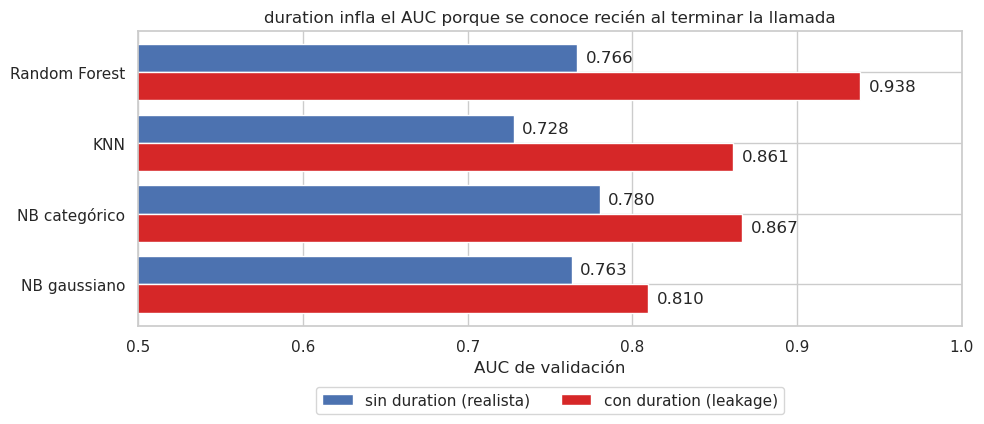

In [18]:
benchmark_drop = tuple(f for f in excluded_features if f != 'duration')
benchmark_rows = []
for model_name, (model, discretize, n_jobs) in fast_models.items():
    realistic = cross_validate_scores(
        make_pipeline(model, discretize=discretize), X_dev, y_dev, n_jobs)['val_auc'].mean()
    leaky = cross_validate_scores(
        make_pipeline(
            model, drop=benchmark_drop, numeric=tuple(model_numeric) + ('duration',),
            log_columns=tuple(log_features) + ('duration',), discretize=discretize,
        ), X_dev, y_dev, n_jobs)['val_auc'].mean()
    benchmark_rows.append({'modelo': model_name, 'sin duration': realistic, 'con duration': leaky})
duration_benchmark = pd.DataFrame(benchmark_rows).set_index('modelo')
display(duration_benchmark.round(3))

fig, axis = plt.subplots(figsize=(10, 4.5))
positions = np.arange(len(duration_benchmark))
axis.barh(positions + 0.2, duration_benchmark['sin duration'], height=0.4, label='sin duration (realista)')
axis.barh(positions - 0.2, duration_benchmark['con duration'], height=0.4, color='tab:red', label='con duration (leakage)')
for position, (without, with_) in enumerate(duration_benchmark.to_numpy()):
    axis.text(without + 0.005, position + 0.2, f'{without:.3f}', va='center')
    axis.text(with_ + 0.005, position - 0.2, f'{with_:.3f}', va='center')
axis.set_yticks(positions, duration_benchmark.index)
axis.set_xlim(0.5, 1)
axis.set_xlabel('AUC de validación')
axis.set_title('duration infla el AUC porque se conoce recién al terminar la llamada')
axis.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2)
plt.tight_layout()
plt.show()

## 7. Comparación de clasificadores

Se comparan los cuatro clasificadores con los hiperparámetros por defecto de scikit-learn. [P02, p. 2] El ajuste de hiperparámetros se hace en la sección 8. Como referencia se incluye un clasificador que siempre predice la clase mayoritaria.

Para Naive Bayes se prueban dos variantes, porque los datos mezclan variables numéricas y categóricas:

- **Gaussiano:** modela cada columna como una normal por clase. [T06, p. 22] [T06, p. 32] Las columnas one-hot y `default_no` son binarias, no gaussianas, así que el supuesto se viola a propósito: se usa como versión simple.
- **Categórico:** discretiza las numéricas en 5 tramos y estima frecuencias por clase con corrección de Laplace (`alpha = 1`). [T06, p. 38] [T06, p. 43] [T06, p. 44] Respeta mejor la naturaleza discreta de los datos.

Las dos variantes comparten el supuesto de independencia condicional entre atributos. [T06, p. 38] SVM no produce probabilidades por defecto: su score es la distancia con signo al hiperplano (`decision_function`), y el umbral se expresa en esa escala.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC

candidates = {
    'Referencia (siempre no)': (make_pipeline(DummyClassifier(strategy='prior')), N_FOLDS, False),
    'Naive Bayes gaussiano': (make_pipeline(GaussianNB()), N_FOLDS, True),
    'Naive Bayes categórico': (make_pipeline(CategoricalNB(alpha=1.0), discretize=True), N_FOLDS, True),
    'KNN': (make_pipeline(KNeighborsClassifier()), N_FOLDS, True),
    'Random Forest': (make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)), 1, True),
    'SVM (RBF)': (make_pipeline(SVC(random_state=RANDOM_STATE)), N_FOLDS, True),
}

summaries, curves = [], {}
for name, (pipeline, n_jobs, choose_threshold) in candidates.items():
    summary, curve = evaluate(name, pipeline, n_jobs=n_jobs, choose_threshold=choose_threshold)
    summaries.append(summary)
    curves[name] = curve
    print(f"{name}: AUC val {summary['auc_val']:.3f}, recall val {summary['recall_val']:.3f}")

base_results = pd.DataFrame(summaries).set_index('modelo')

Referencia (siempre no): AUC val 0.500, recall val 0.000


Naive Bayes gaussiano: AUC val 0.763, recall val 0.683


Naive Bayes categórico: AUC val 0.780, recall val 0.682


KNN: AUC val 0.728, recall val 0.668


Random Forest: AUC val 0.766, recall val 0.662


SVM (RBF): AUC val 0.700, recall val 0.576


### 7.1 Resultados con hiperparámetros por defecto

,auc_train,auc_val,auc_val_std,recall_val,recall_val_std,precision_val,especificidad_val,recall_umbral_defecto,umbral
modelo,,,,,,,,,
Referencia (siempre no),0.500,0.500,0.000,0.000,0.000,0.000,1.000,0.000,nan
Naive Bayes gaussiano,0.773,0.763,0.010,0.683,0.013,0.252,0.743,0.460,0.0002296
Naive Bayes categórico,0.793,0.780,0.009,0.682,0.018,0.279,0.776,0.565,0.08103
KNN,0.928,0.728,0.004,0.668,0.006,0.218,0.697,0.278,0.2
Random Forest,0.999,0.766,0.009,0.662,0.012,0.269,0.772,0.296,0.102
SVM (RBF),0.849,0.700,0.007,0.576,0.016,0.246,0.777,0.240,-1


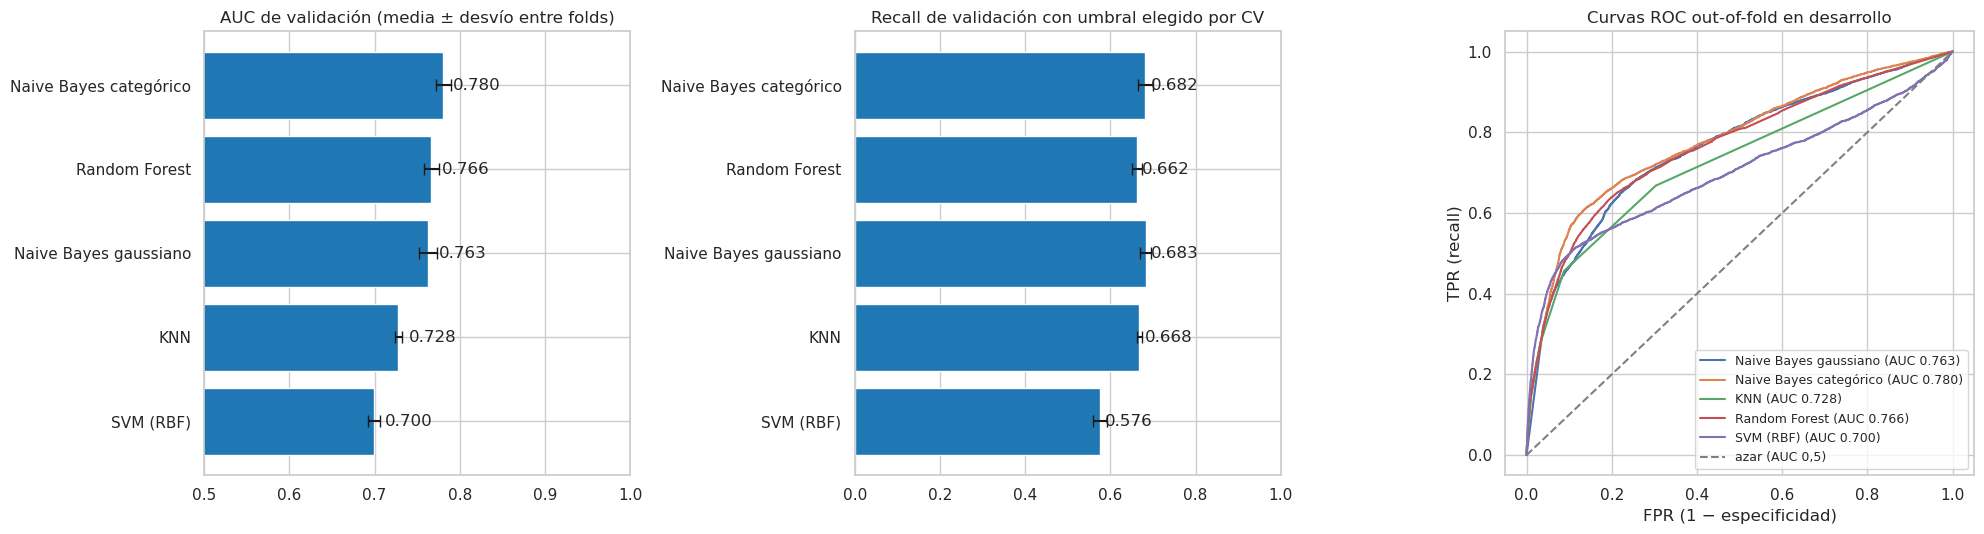

In [20]:
display(base_results.drop(columns='segundos').style.format({
    column: '{:.3f}' for column in base_results.columns if column not in ('umbral', 'segundos')
} | {'umbral': '{:.4g}'}))

plot_results = base_results.drop(index='Referencia (siempre no)').sort_values('auc_val')
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), gridspec_kw={'width_ratios': [1, 1, 1.1]})

for axis, (column, std, title, x_min) in zip(axes[:2], [
    ('auc_val', 'auc_val_std', 'AUC de validación (media ± desvío entre folds)', 0.5),
    ('recall_val', 'recall_val_std', 'Recall de validación con umbral elegido por CV', 0.0),
]):
    axis.barh(plot_results.index, plot_results[column], xerr=plot_results[std], color='tab:blue', capsize=4)
    for position, value in enumerate(plot_results[column]):
        axis.text(value + 0.012, position, f'{value:.3f}', va='center')
    axis.set_title(title)
    axis.set_xlim(x_min, 1)

for name, curve in curves.items():
    if name == 'Referencia (siempre no)':
        continue
    axes[2].plot(curve['fpr'], curve['tpr'], label=f"{name} (AUC {base_results.loc[name, 'auc_val']:.3f})")
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--', label='azar (AUC 0,5)')
axes[2].set_xlabel('FPR (1 − especificidad)')
axes[2].set_ylabel('TPR (recall)')
axes[2].set_title('Curvas ROC out-of-fold en desarrollo')
axes[2].legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Ajuste de hiperparámetros

Para cada modelo se traza una curva de validación: AUC de entrenamiento y de validación en función de un hiperparámetro de complejidad. Un gap grande indica sobreajuste. Un gap chico con AUC bajo indica subajuste. [P02, p. 2] [T07, p. 50] Se elige el valor con mayor AUC medio de validación. Cuando varios valores quedan dentro del desvío entre folds, se prefiere el más simple o más barato. Test no interviene. [T02, p. 89]

In [21]:
def validation_curve_auc(build_pipeline, values, n_jobs=N_FOLDS):
    rows = []
    for value in values:
        cvr = cross_validate_scores(build_pipeline(value), X_dev, y_dev, n_jobs)
        rows.append({
            'valor': value,
            'auc_train': cvr['train_auc'].mean(), 'auc_train_std': cvr['train_auc'].std(),
            'auc_val': cvr['val_auc'].mean(), 'auc_val_std': cvr['val_auc'].std(),
        })
    return pd.DataFrame(rows)


def plot_validation_curve(axis, curve, label='', positions=None, color=None):
    x = curve['valor'] if positions is None else positions
    for column, style in [('auc_train', '--'), ('auc_val', '-')]:
        axis.plot(x, curve[column], style, marker='o', color=color,
                  label=f"{'train' if column == 'auc_train' else 'validación'}{label}")
        axis.fill_between(x, curve[column] - curve[f'{column}_std'],
                          curve[column] + curve[f'{column}_std'], alpha=0.15, color=color)
    axis.set_ylabel('AUC')
    axis.legend()


def best_value(curve):
    return curve.loc[curve['auc_val'].idxmax(), 'valor']

### 8.1 KNN: número de vecinos y ponderación

`k` chico tiene bajo sesgo y alta varianza; `k` grande, más estabilidad y más sesgo. [T09, p. 29] Con la ponderación por distancia, cada vecino pesa la inversa de su distancia. [T09, p. 34] Se usan valores impares de `k` para evitar empates. [T09, p. 31]

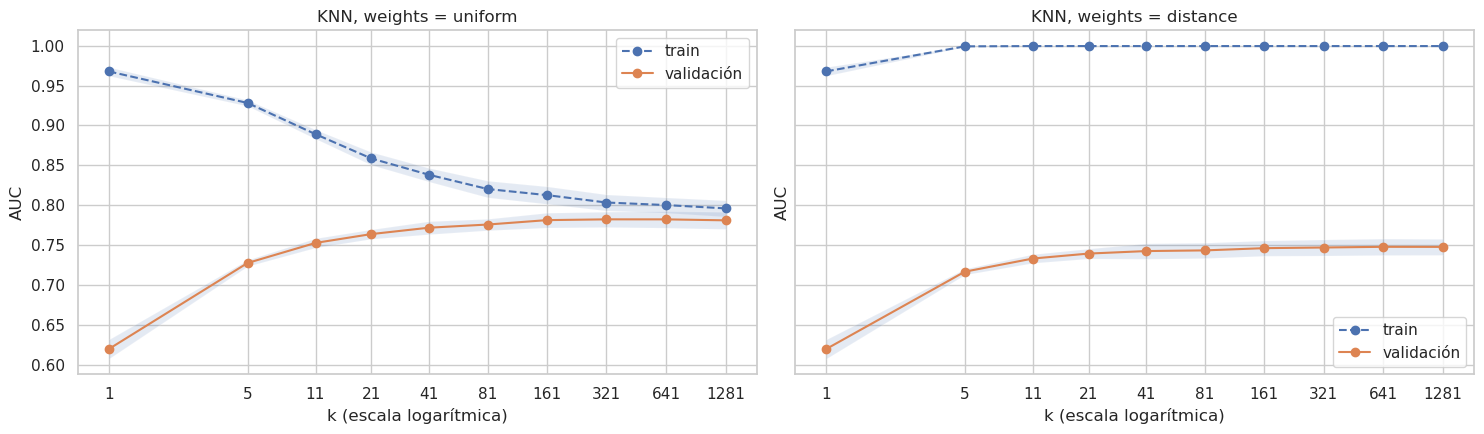

,weights,valor,auc_train,auc_train_std,auc_val,auc_val_std
0,uniform,1,0.968,0.005,0.620,0.012
1,uniform,5,0.928,0.004,0.728,0.004
2,uniform,11,0.889,0.006,0.753,0.006
3,uniform,21,0.859,0.008,0.764,0.006
4,uniform,41,0.838,0.008,0.772,0.008
5,uniform,81,0.820,0.010,0.776,0.007
6,uniform,161,0.813,0.011,0.781,0.009
7,uniform,321,0.804,0.010,0.782,0.010
8,uniform,641,0.800,0.010,0.782,0.010
9,uniform,1281,0.796,0.010,0.781,0.011


Mejor configuración: k = 321, weights = uniform, AUC val = 0.782


In [22]:
k_values = [1, 5, 11, 21, 41, 81, 161, 321, 641, 1281]
knn_curves = {
    weights: validation_curve_auc(
        lambda k, w=weights: make_pipeline(KNeighborsClassifier(n_neighbors=k, weights=w)), k_values)
    for weights in ['uniform', 'distance']
}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for axis, (weights, curve) in zip(axes, knn_curves.items()):
    plot_validation_curve(axis, curve)
    axis.set_xscale('log')
    axis.set_xticks(k_values, [str(k) for k in k_values])
    axis.set_xlabel('k (escala logarítmica)')
    axis.set_title(f'KNN, weights = {weights}')
plt.tight_layout()
plt.show()

knn_table = pd.concat(knn_curves, names=['weights']).reset_index(level=0).reset_index(drop=True)
best_knn = knn_table.loc[knn_table['auc_val'].idxmax()]
best_k, best_weights = int(best_knn['valor']), best_knn['weights']
display(knn_table.round(3))
print(f'Mejor configuración: k = {best_k}, weights = {best_weights}, AUC val = {best_knn.auc_val:.3f}')

### 8.2 Random Forest: profundidad máxima y número de árboles

Primero se recorre `max_depth` con 100 árboles. Después, con la mejor profundidad, se recorre `n_estimators`. Más árboles dan más estabilidad, hasta cierto punto. [T07, p. 61] Una profundidad mayor permite más divisiones y una salida más sensible a los datos. [T09, p. 70]

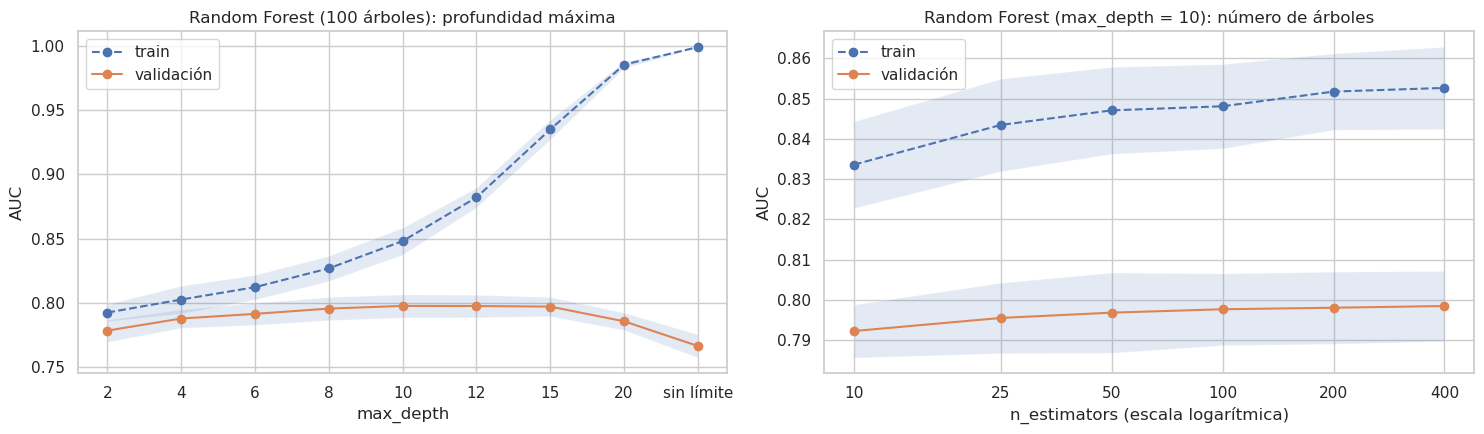

,valor,auc_train,auc_train_std,auc_val,auc_val_std
0,2,0.792,0.007,0.778,0.009
1,4,0.803,0.011,0.788,0.007
2,6,0.812,0.010,0.791,0.009
3,8,0.827,0.010,0.796,0.009
4,10,0.848,0.010,0.798,0.009
5,12,0.882,0.008,0.798,0.009
6,15,0.935,0.008,0.797,0.007
7,20,0.985,0.002,0.786,0.007
8,sin límite,0.999,0.000,0.766,0.009


,valor,auc_train,auc_train_std,auc_val,auc_val_std
0,10,0.834,0.011,0.792,0.007
1,25,0.843,0.011,0.795,0.009
2,50,0.847,0.011,0.797,0.010
3,100,0.848,0.010,0.798,0.009
4,200,0.852,0.009,0.798,0.009
5,400,0.853,0.010,0.798,0.009


In [23]:
depth_values = [2, 4, 6, 8, 10, 12, 15, 20, None]
rf_depth_curve = validation_curve_auc(
    lambda depth: make_pipeline(RandomForestClassifier(
        n_estimators=100, max_depth=depth, random_state=RANDOM_STATE, n_jobs=-1)),
    depth_values, n_jobs=1)
best_depth = best_value(rf_depth_curve)
best_depth = None if pd.isna(best_depth) else int(best_depth)

tree_values = [10, 25, 50, 100, 200, 400]
rf_trees_curve = validation_curve_auc(
    lambda trees: make_pipeline(RandomForestClassifier(
        n_estimators=trees, max_depth=best_depth, random_state=RANDOM_STATE, n_jobs=-1)),
    tree_values, n_jobs=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
depth_labels = [str(d) if d is not None else 'sin límite' for d in depth_values]
plot_validation_curve(axes[0], rf_depth_curve, positions=np.arange(len(depth_values)))
axes[0].set_xticks(np.arange(len(depth_values)), depth_labels)
axes[0].set_xlabel('max_depth')
axes[0].set_title('Random Forest (100 árboles): profundidad máxima')
plot_validation_curve(axes[1], rf_trees_curve)
axes[1].set_xscale('log')
axes[1].set_xticks(tree_values, [str(t) for t in tree_values])
axes[1].set_xlabel('n_estimators (escala logarítmica)')
axes[1].set_title(f'Random Forest (max_depth = {best_depth}): número de árboles')
plt.tight_layout()
plt.show()

display(rf_depth_curve.assign(valor=depth_labels).round(3))
display(rf_trees_curve.round(3))

### 8.3 SVM: parámetro `C`, balanceo de clases y kernel

En scikit-learn, `C` es el costo de violar el margen: un `C` chico regulariza más y uno grande prioriza el ajuste a los datos de entrenamiento. [T08, p. 49] Es la convención de la diapositiva del kernel RBF. La formulación del margen tolerante usa `C` como presupuesto de holguras, con el sentido opuesto. [T08, p. 30]

**Conocimiento general:** con `class_weight='balanced'`, el costo de violar el margen se multiplica por `n / (2 · n_clase)`. En desarrollo, eso da alrededor de 4,4 para un positivo y 0,56 para un negativo. Sin ese balanceo, con 11 % de positivos y clases muy superpuestas, la solución de margen favorece a la clase mayoritaria y el score de SVM ordena peor a los clientes. Una prueba sobre un fold mostró una mejora grande, así que se recorre `C` con y sin balanceo. Después, con la mejor configuración, se comparan los kernels lineal, polinómico y RBF. [T08, p. 43] [T08, p. 44] [T08, p. 46]

El parámetro `γ` del kernel RBF se dejó en el valor por defecto (`'scale'`). En la misma prueba, valores entre 0,001 y 0,078 cambiaron el AUC menos de 0,02.

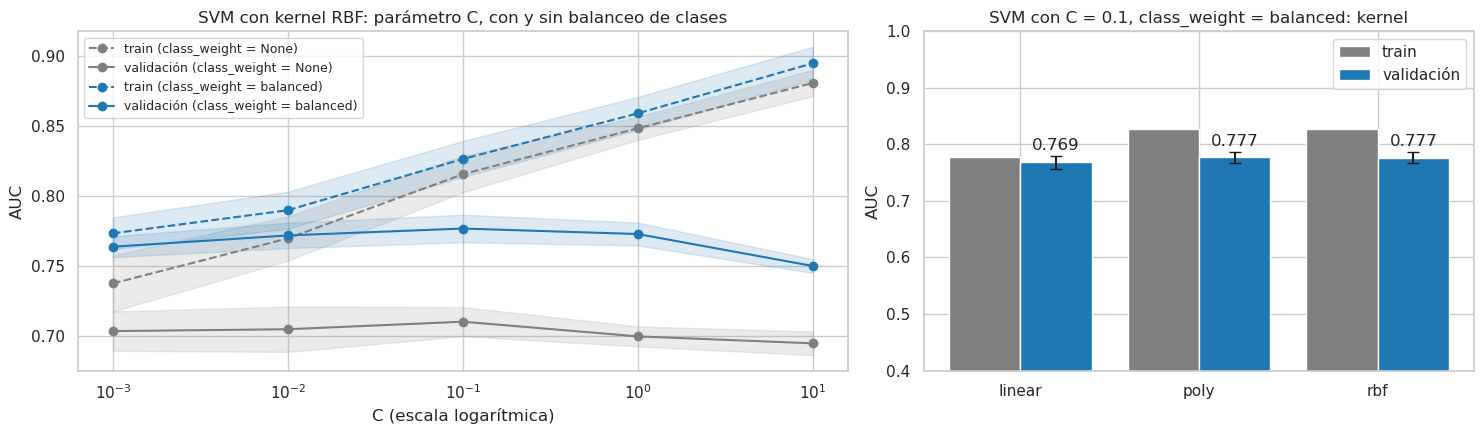

,class_weight,valor,auc_train,auc_train_std,auc_val,auc_val_std
0,None,0.001,0.737,0.020,0.703,0.014
1,None,0.010,0.770,0.016,0.705,0.016
2,None,0.100,0.816,0.013,0.710,0.010
3,None,1.000,0.849,0.008,0.700,0.007
4,None,10.000,0.881,0.009,0.695,0.008
5,balanced,0.001,0.773,0.011,0.764,0.007
6,balanced,0.010,0.790,0.013,0.772,0.009
7,balanced,0.100,0.827,0.013,0.777,0.010
8,balanced,1.000,0.859,0.012,0.773,0.008
9,balanced,10.000,0.895,0.012,0.750,0.005


,valor,auc_train,auc_train_std,auc_val,auc_val_std
0,linear,0.778,0.009,0.769,0.012
1,poly,0.827,0.011,0.777,0.009
2,rbf,0.827,0.013,0.777,0.010


Mejor configuración: C = 0.1, class_weight = balanced, kernel = poly


In [24]:
c_values = [0.001, 0.01, 0.1, 1, 10]
svm_c_curves = {
    weight: validation_curve_auc(
        lambda c, w=weight: make_pipeline(SVC(C=c, kernel='rbf', class_weight=w, random_state=RANDOM_STATE)),
        c_values)
    for weight in [None, 'balanced']
}
svm_table = pd.concat(
    {str(weight): curve for weight, curve in svm_c_curves.items()}, names=['class_weight']
).reset_index(level=0).reset_index(drop=True)
best_svm = svm_table.loc[svm_table['auc_val'].idxmax()]
best_c = float(best_svm['valor'])
best_class_weight = None if best_svm['class_weight'] == 'None' else best_svm['class_weight']

kernel_values = ['linear', 'poly', 'rbf']
svm_kernel_curve = validation_curve_auc(
    lambda kernel: make_pipeline(SVC(C=best_c, kernel=kernel, class_weight=best_class_weight,
                                     random_state=RANDOM_STATE)),
    kernel_values)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={'width_ratios': [1.4, 1]})
for (weight, curve), color in zip(svm_c_curves.items(), ['tab:gray', 'tab:blue']):
    plot_validation_curve(axes[0], curve, label=f' (class_weight = {weight})', color=color)
axes[0].set_xscale('log')
axes[0].set_xlabel('C (escala logarítmica)')
axes[0].set_title('SVM con kernel RBF: parámetro C, con y sin balanceo de clases')
axes[0].legend(fontsize=9)

positions = np.arange(len(kernel_values))
axes[1].bar(positions - 0.2, svm_kernel_curve['auc_train'], width=0.4, label='train', color='tab:gray')
axes[1].bar(positions + 0.2, svm_kernel_curve['auc_val'], width=0.4, yerr=svm_kernel_curve['auc_val_std'],
            label='validación', color='tab:blue', capsize=4)
for position, value, std in zip(positions, svm_kernel_curve['auc_val'], svm_kernel_curve['auc_val_std']):
    axes[1].text(position + 0.2, value + std + 0.01, f'{value:.3f}', ha='center')
axes[1].set_xticks(positions, kernel_values)
axes[1].set_ylim(0.4, 1)
axes[1].set_ylabel('AUC')
axes[1].set_title(f'SVM con C = {best_c:g}, class_weight = {best_class_weight}: kernel')
axes[1].legend()
plt.tight_layout()
plt.show()

display(svm_table.round(3))
display(svm_kernel_curve.round(3))
best_kernel = best_value(svm_kernel_curve)
print(f'Mejor configuración: C = {best_c:g}, class_weight = {best_class_weight}, kernel = {best_kernel}')

### 8.4 Random Forest ajustado y las variables `housing`, `loan` y `day_of_week`

En la sección 6.1, agregar estas variables mejoraba al Random Forest con hiperparámetros por defecto, que sobreajusta (AUC de train 0,999). Se repite la comparación con el Random Forest ajustado.

In [25]:
best_trees = int(best_value(rf_trees_curve))
tuned_rf = RandomForestClassifier(
    n_estimators=best_trees, max_depth=best_depth, random_state=RANDOM_STATE, n_jobs=-1)
rf_extra_drop = tuple(c for c in excluded_features if c not in ('housing', 'loan', 'day_of_week'))
rf_with_extra = cross_validate_scores(
    make_pipeline(tuned_rf, drop=rf_extra_drop,
                  categorical=tuple(model_categorical) + ('housing', 'loan', 'day_of_week')),
    X_dev, y_dev, 1)
rf_without_extra = cross_validate_scores(make_pipeline(tuned_rf), X_dev, y_dev, 1)
print(f'Random Forest ajustado (max_depth = {best_depth}, n_estimators = {best_trees})')
print(f"  sin housing, loan, day_of_week: AUC val {rf_without_extra['val_auc'].mean():.4f}")
print(f"  con housing, loan, day_of_week: AUC val {rf_with_extra['val_auc'].mean():.4f}")

Random Forest ajustado (max_depth = 10, n_estimators = 400)
  sin housing, loan, day_of_week: AUC val 0.7984
  con housing, loan, day_of_week: AUC val 0.7979


## 9. Comparación de los modelos ajustados

Se evalúa cada modelo con su mejor configuración, con el mismo esquema de la sección 7: AUC, umbral elegido por la curva ROC *out-of-fold* y recall con ese umbral. Naive Bayes no se ajustó, porque la consigna pide ajustar SVM, KNN y RF. [P02, p. 2]

In [26]:
tuned_candidates = {
    'Naive Bayes gaussiano': (make_pipeline(GaussianNB()), N_FOLDS),
    'Naive Bayes categórico': (make_pipeline(CategoricalNB(alpha=1.0), discretize=True), N_FOLDS),
    f'KNN (k = {best_k}, {best_weights})': (
        make_pipeline(KNeighborsClassifier(n_neighbors=best_k, weights=best_weights)), N_FOLDS),
    f'Random Forest (depth = {best_depth}, {best_trees} árboles)': (make_pipeline(tuned_rf), 1),
    f'SVM ({best_kernel}, C = {best_c:g}, {best_class_weight})': (
        make_pipeline(SVC(C=best_c, kernel=best_kernel, class_weight=best_class_weight,
                          random_state=RANDOM_STATE)), N_FOLDS),
}

tuned_summaries, tuned_curves = [], {}
for name, (pipeline, n_jobs) in tuned_candidates.items():
    summary, curve = evaluate(name, pipeline, n_jobs=n_jobs)
    tuned_summaries.append(summary)
    tuned_curves[name] = curve
tuned_results = pd.DataFrame(tuned_summaries).set_index('modelo')
display(tuned_results.drop(columns='segundos').style.format({
    column: '{:.3f}' for column in tuned_results.columns if column not in ('umbral', 'segundos')
} | {'umbral': '{:.4g}'}))

,auc_train,auc_val,auc_val_std,recall_val,recall_val_std,precision_val,especificidad_val,recall_umbral_defecto,umbral
modelo,,,,,,,,,
Naive Bayes gaussiano,0.773,0.763,0.010,0.683,0.013,0.252,0.743,0.460,0.0002296
Naive Bayes categórico,0.793,0.780,0.009,0.682,0.018,0.279,0.776,0.565,0.08103
"KNN (k = 321, uniform)",0.804,0.782,0.010,0.671,0.023,0.276,0.776,0.163,0.08723
"Random Forest (depth = 10, 400 árboles)",0.853,0.798,0.009,0.690,0.012,0.290,0.786,0.230,0.084
"SVM (poly, C = 0.1, balanced)",0.827,0.777,0.009,0.685,0.013,0.280,0.777,0.596,-0.8553


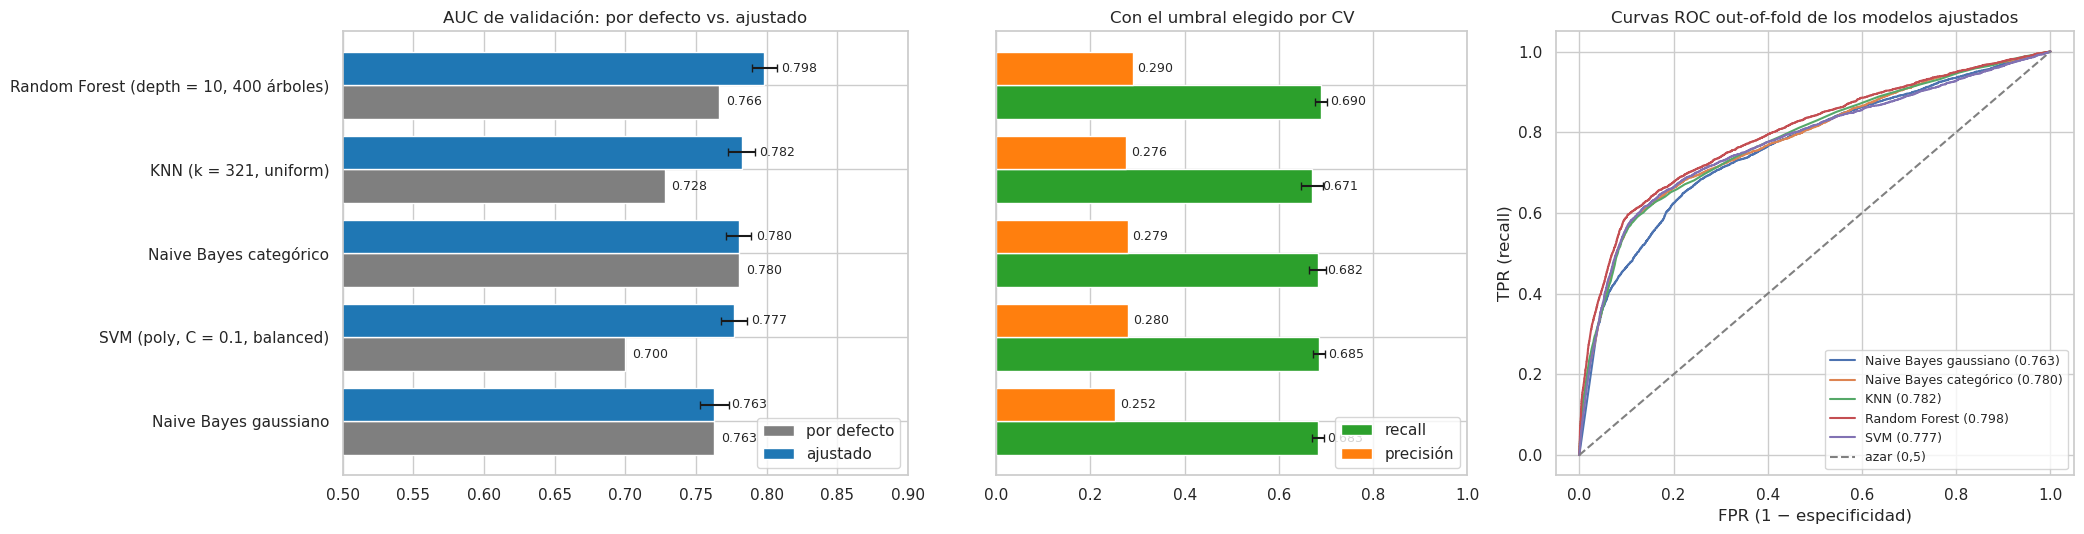

In [27]:
family = lambda name: name.split(' (')[0]
default_auc = base_results['auc_val'].rename(index=family)
comparison = tuned_results[['auc_val', 'auc_val_std', 'recall_val', 'recall_val_std', 'precision_val']].copy()
comparison['auc_val_defecto'] = [default_auc[family(name)] for name in comparison.index]
comparison = comparison.sort_values('auc_val')

fig, axes = plt.subplots(1, 3, figsize=(21, 5.5), gridspec_kw={'width_ratios': [1.2, 1, 1.1]})
positions = np.arange(len(comparison))
axes[0].barh(positions - 0.2, comparison['auc_val_defecto'], height=0.4, color='tab:gray', label='por defecto')
axes[0].barh(positions + 0.2, comparison['auc_val'], height=0.4, xerr=comparison['auc_val_std'],
             color='tab:blue', capsize=3, label='ajustado')
for position, (default, tuned) in enumerate(comparison[['auc_val_defecto', 'auc_val']].to_numpy()):
    axes[0].text(default + 0.005, position - 0.2, f'{default:.3f}', va='center', fontsize=9)
    axes[0].text(tuned + 0.012, position + 0.2, f'{tuned:.3f}', va='center', fontsize=9)
axes[0].set_yticks(positions, comparison.index)
axes[0].set_xlim(0.5, 0.9)
axes[0].set_title('AUC de validación: por defecto vs. ajustado')
axes[0].legend(loc='lower right')

axes[1].barh(positions - 0.2, comparison['recall_val'], height=0.4, xerr=comparison['recall_val_std'],
             capsize=3, color='tab:green', label='recall')
axes[1].barh(positions + 0.2, comparison['precision_val'], height=0.4, color='tab:orange', label='precisión')
for position, (recall, precision) in enumerate(comparison[['recall_val', 'precision_val']].to_numpy()):
    axes[1].text(recall + 0.02, position - 0.2, f'{recall:.3f}', va='center', fontsize=9)
    axes[1].text(precision + 0.01, position + 0.2, f'{precision:.3f}', va='center', fontsize=9)
axes[1].set_yticks(positions, [''] * len(positions))
axes[1].set_xlim(0, 1)
axes[1].set_title('Con el umbral elegido por CV')
axes[1].legend(loc='lower right')

for name, curve in tuned_curves.items():
    axes[2].plot(curve['fpr'], curve['tpr'], label=f"{family(name)} ({tuned_results.loc[name, 'auc_val']:.3f})")
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--', label='azar (0,5)')
axes[2].set_xlabel('FPR (1 − especificidad)')
axes[2].set_ylabel('TPR (recall)')
axes[2].set_title('Curvas ROC out-of-fold de los modelos ajustados')
axes[2].legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()